# Plateau consistency check

In [1]:
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
if "get_ipython" not in globals():
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.interpolate import RegularGridInterpolator

CURVE_FILE = Path("data") / "vcdm_R_scan.npz"
FIG_DIR = Path("fig")
PLATEAU_TABLE = Path("data") / "genesis_scan_table.csv"


N_PLATEAU_POINTS = 15


REL_TOL = 0.01

In [2]:
curves = np.load(CURVE_FILE)
table = pd.read_csv(PLATEAU_TABLE)

required_curve_keys = {"d", "alpha0", "kappa", "x", "R_abs"}
required_table_cols = {"alpha", "d", "kappa", "Ps"}
missing_curve = required_curve_keys.difference(curves.files)
missing_table = required_table_cols.difference(table.columns)
assert not missing_curve, f"Missing curve keys: {sorted(missing_curve)}"
assert not missing_table, f"Missing table columns: {sorted(missing_table)}"


alpha_grid = np.sort(table["alpha"].unique())
d_grid = np.sort(table["d"].unique())
kappa_grid = np.sort(table["kappa"].unique())

expected_rows = len(alpha_grid) * len(d_grid) * len(kappa_grid)
assert expected_rows == len(table), (
    f"Expected a complete grid with {expected_rows} rows, got {len(table)}"
)

ps_cube = (
    table.set_index(["alpha", "d", "kappa"])
    .sort_index()["Ps"]
    .to_numpy()
    .reshape(len(alpha_grid), len(d_grid), len(kappa_grid))
)

inv_d_grid = (1.0 / d_grid)[::-1]  
interp_log_ps = RegularGridInterpolator(
    (np.log10(alpha_grid), inv_d_grid, np.log10(kappa_grid)),
    np.log(ps_cube)[:, ::-1, :],  
    bounds_error=False,
    fill_value=np.nan,
)

points = np.column_stack([
    np.log10(curves["alpha0"]),
    1.0 / curves["d"],
    np.log10(curves["kappa"]),
])
ps_table = np.exp(interp_log_ps(points))
assert np.isfinite(ps_table).all(), "Some curve points are outside the table grid."


x = curves["x"]
R_abs = curves["R_abs"]
assert x.ndim == 2 and R_abs.ndim == 2 and x.shape == R_abs.shape
assert np.nanmedian(x[:, 0]) < np.nanmedian(x[:, -1]), (
    "Expected plateau points at the beginning of each curve."
)

R_plateau = np.nanmedian(R_abs[:, :N_PLATEAU_POINTS], axis=1)
ps_curve = curves["kappa"]**3 * R_plateau**2 / (2.0 * np.pi**2)

rel = ps_curve / ps_table - 1.0
abs_rel = np.abs(rel)
plateau_drift = (
    np.nanmax(R_abs[:, :N_PLATEAU_POINTS], axis=1)
    / np.nanmin(R_abs[:, :N_PLATEAU_POINTS], axis=1)
    - 1.0
)

summary = pd.DataFrame({
    "quantity": [
        "curves checked",
        "plateau points used",
        "median abs rel diff [%]",
        "max abs rel diff [%]",
        "max plateau drift in used points [%]",
    ],
    "value": [
        len(rel),
        N_PLATEAU_POINTS,
        100.0 * np.median(abs_rel),
        100.0 * abs_rel.max(),
        100.0 * plateau_drift.max(),
    ],
})

display(summary)

worst = pd.DataFrame({
    "model_id": np.arange(len(rel)),
    "d": curves["d"],
    "alpha0": curves["alpha0"],
    "kappa": curves["kappa"],
    "Ps_curve": ps_curve,
    "Ps_table_interp": ps_table,
    "rel_diff_percent": 100.0 * rel,
    "plateau_drift_percent": 100.0 * plateau_drift,
})
worst["abs_rel_diff_percent"] = worst["rel_diff_percent"].abs()
worst = worst.sort_values("abs_rel_diff_percent", ascending=False).head(10)
display(worst)

assert abs_rel.max() <= REL_TOL, (
    f"Plateau mismatch exceeds tolerance: max={100*abs_rel.max():.3f}% "
    f"> {100*REL_TOL:.3f}%"
)
print(f"PASS: all curve plateaus agree with the table within {100*REL_TOL:.2f}%.")

,quantity,value
0,curves checked,4096.000000
1,plateau points used,15.000000
2,median abs rel diff [%],0.018519
3,max abs rel diff [%],0.277107
4,max plateau drift in used points [%],0.000007


,model_id,d,alpha0,kappa,Ps_curve,Ps_table_interp,rel_diff_percent,plateau_drift_percent,abs_rel_diff_percent
348,348,0.115552,6.412639e-22,2.965464e-09,6.348316e+14,6.330773e+14,0.277107,0.000002,0.277107
4064,4064,0.102104,1.259469e-26,1.295361e-08,2.986009e+18,2.980242e+18,0.193493,0.000001,0.193493
2244,2244,0.102119,3.410126e-28,1.269157e-08,1.111708e+20,1.109814e+20,0.170606,0.000001,0.170606
2890,2890,0.101356,5.653905e-23,1.273092e-08,5.842494e+14,5.833250e+14,0.158466,0.000001,0.158466
3517,3517,0.117353,6.922996e-23,5.684632e-07,1.953385e+15,1.950400e+15,0.153045,0.000001,0.153045
992,992,0.104140,1.165970e-30,1.021189e-08,4.897376e+22,4.889973e+22,0.151401,0.000001,0.151401
1928,1928,0.101296,1.143319e-23,1.079979e-09,5.342980e+15,5.335247e+15,0.144931,0.000002,0.144931
1153,1153,0.105928,2.200307e-25,3.888531e-09,4.425660e+17,4.419522e+17,0.138884,0.000002,0.138884
1836,1836,0.139210,2.044757e-29,2.431262e-08,1.581591e+23,1.579435e+23,0.136523,0.000002,0.136523
1322,1322,0.101783,6.543853e-25,1.777314e-09,9.036971e+16,9.025076e+16,0.131806,0.000002,0.131806


PASS: all curve plateaus agree with the table within 1.00%.


wrote fig\plateau_consistency.png


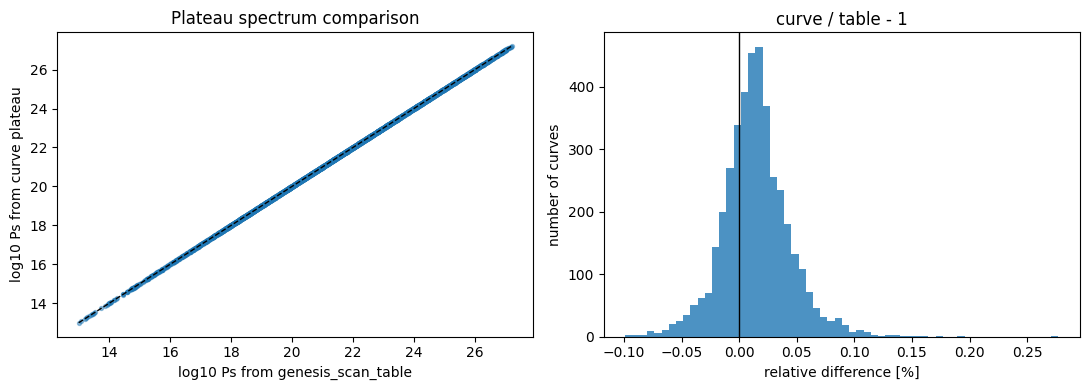

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

log_table = np.log10(ps_table)
log_curve = np.log10(ps_curve)
lo = min(log_table.min(), log_curve.min())
hi = max(log_table.max(), log_curve.max())

axes[0].scatter(log_table, log_curve, s=8, alpha=0.45)
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1)
axes[0].set_xlabel("log10 Ps from genesis_scan_table")
axes[0].set_ylabel("log10 Ps from curve plateau")
axes[0].set_title("Plateau spectrum comparison")

axes[1].hist(100.0 * rel, bins=60, color="C0", alpha=0.8)
axes[1].axvline(0.0, color="k", lw=1)
axes[1].set_xlabel("relative difference [%]")
axes[1].set_ylabel("number of curves")
axes[1].set_title("curve / table - 1")

fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
f = FIG_DIR / "plateau_consistency.png"
fig.savefig(f, bbox_inches="tight")
print(f"wrote {f}")
if matplotlib.get_backend().lower() == "agg":
    plt.close(fig)
else:
    plt.show()

## Analytic fit plateau vs numerical plateau

analytic fit plateau (full model) vs table Ps:
  median |rel| = 0.0889 %
  p95    |rel| = 0.2328 %
  max    |rel| = 0.4539 %
wrote fig\plateau_fit_vs_table.png


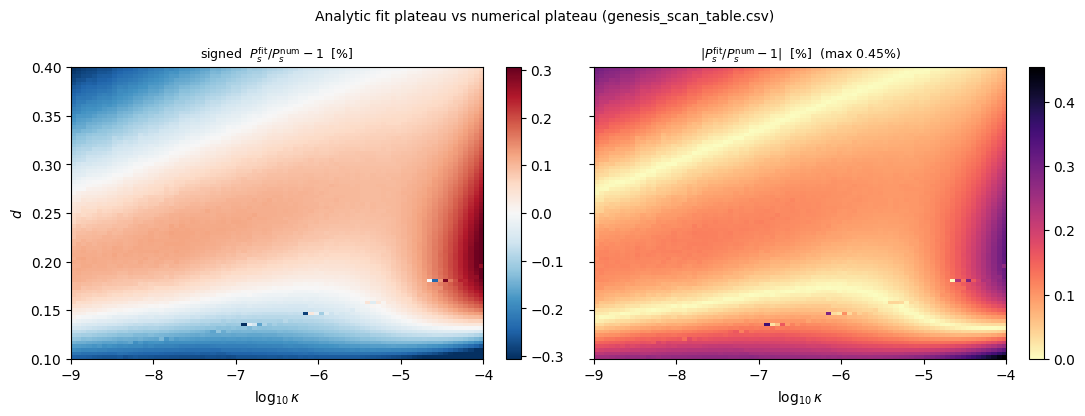

In [4]:
import json

from scipy.special import airy

import genesis_background as gb


X_FINAL = 1e-6
NRM = 0.5 * np.log(np.pi / 2.0)

_cfg = json.loads((Path("data") / "fit_curve_constants.json").read_text())
_c = _cfg["constants"]
p1, p_d, p_C = _c["P:one"], _c["P:d"], _c["P:logC"]
w_B2, w_V = _c["B2:one"], _c["V:one"]
zeta_star, q_sw = _cfg["blend"]["zeta_star"], _cfg["blend"]["q_sw"]


def fit_plateau_lnR(d, alpha0, kappa):
    """ln|R_plateau| from the full fitted model, evaluated at x_final."""
    x = np.full_like(d, X_FINAL)
    lnz = np.log(np.sqrt(np.abs(gb.z_squared(x, d, alpha0, kappa))))
    o2 = gb.omega2(x, d, alpha0, kappa)
    xt = 1.0 / kappa                                       # Newton -> last turning point
    for _ in range(6):
        h = 1e-4
        f = gb.omega2(xt, d, alpha0, kappa)
        fp = (gb.omega2(xt * (1 + h), d, alpha0, kappa)
              - gb.omega2(xt * (1 - h), d, alpha0, kappa)) / (2 * h * xt)
        xt = xt - np.clip(f / fp, -0.5 * xt, 0.5 * xt)
    s = (gb.omega2(xt * (1 + 1e-4), d, alpha0, kappa)
         - gb.omega2(xt * (1 - 1e-4), d, alpha0, kappa)) / (2e-4 * xt)
    zeta = -np.sign(s) * np.abs(s) ** (1 / 3) * (x - xt)
    zc = np.clip(zeta, -1e6, 40.0)
    Ai, _, Bi, _ = airy(zc)
    P = (np.abs(zc) / np.maximum(np.abs(o2), 1e-300)) ** 0.25
    P = np.where(np.abs(x - xt) < x * 1e-3, np.abs(s) ** (-1 / 6.0), P)
    uni = NRM + np.log(P) + 0.5 * np.log(Ai**2 + Bi**2) - lnz
    L0, logC = gb.L0_logC(d, alpha0, kappa)
    de = L0 + p1 + p_d * d + p_C * logC
    W = np.where(zeta <= 0, 1.0,
                 1.0 / (1.0 + np.exp(np.clip(q_sw * (zeta - zeta_star), -60, 60))))
    B2 = np.exp(-0.5 * ((np.log(kappa * x) + 0.45) / 0.50) ** 2)
    return W * uni + (1.0 - W) * de + w_B2 * B2 + w_V * 4.0 * W * (1.0 - W)


d_tab = table["d"].to_numpy()
alpha_tab = table["alpha"].to_numpy()
kappa_tab = table["kappa"].to_numpy()
lnR_fit = fit_plateau_lnR(d_tab, alpha_tab, kappa_tab)
ps_fit = kappa_tab**3 * np.exp(2.0 * lnR_fit) / (2.0 * np.pi**2)
rel_fit = ps_fit / table["Ps"].to_numpy() - 1.0

print("analytic fit plateau (full model) vs table Ps:")
print(f"  median |rel| = {100 * np.median(np.abs(rel_fit)):.4f} %")
print(f"  p95    |rel| = {100 * np.percentile(np.abs(rel_fit), 95):.4f} %")
print(f"  max    |rel| = {100 * np.max(np.abs(rel_fit)):.4f} %")


rel_tmp = table.copy()
rel_tmp["rel"] = rel_fit
rel_cube = (
    rel_tmp.set_index(["alpha", "d", "kappa"])
    .sort_index()["rel"]
    .to_numpy()
    .reshape(len(alpha_grid), len(d_grid), len(kappa_grid))
)
signed = 100.0 * np.nanmean(rel_cube, axis=0)            # (d, kappa)
abs_mean = 100.0 * np.nanmean(np.abs(rel_cube), axis=0)

lgk = np.log10(kappa_grid)
extent = [lgk.min(), lgk.max(), d_grid.min(), d_grid.max()]
fig, (ax_s, ax_a) = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)

vmax = np.nanpercentile(np.abs(signed), 99.5)
im_s = ax_s.imshow(signed, origin="lower", aspect="auto", extent=extent,
                   cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax_s.set_title(r"signed  $P_s^{\rm fit}/P_s^{\rm num}-1$  [%]", fontsize=9)
ax_s.set_xlabel(r"$\log_{10}\kappa$")
ax_s.set_ylabel(r"$d$")
fig.colorbar(im_s, ax=ax_s, fraction=0.046)

im_a = ax_a.imshow(abs_mean, origin="lower", aspect="auto", extent=extent,
                   cmap="magma_r", vmin=0)
ax_a.set_title(rf"$|P_s^{{\rm fit}}/P_s^{{\rm num}}-1|$  [%]  (max {abs_mean.max():.2f}%)",
               fontsize=9)
ax_a.set_xlabel(r"$\log_{10}\kappa$")
fig.colorbar(im_a, ax=ax_a, fraction=0.046)

fig.suptitle("Analytic fit plateau vs numerical plateau (genesis_scan_table.csv)", fontsize=10)
fig.tight_layout()
FIG_DIR.mkdir(exist_ok=True)
out = FIG_DIR / "plateau_fit_vs_table.png"
fig.savefig(out, bbox_inches="tight")
print(f"wrote {out}")
if matplotlib.get_backend().lower() == "agg":
    plt.close(fig)
else:
    plt.show()